In [ ]:
from nltk.tokenize import TreebankWordTokenizer
from typing import Dict, List, Tuple, Any
from nltk.tokenize.api import TokenizerI
import pandas as pd
import os
import sklearn_crfsuite
from sklearn_crfsuite import metrics
from pathlib import Path

In [ ]:
tokenizer = TreebankWordTokenizer()

In [ ]:
def data_to_tagging_per_line(
    dataframe: pd.DataFrame,
    tokenizer: TokenizerI,
    documents_dir: str = "../data/documents"
) -> Tuple[Dict[str, List[str]], Dict[str, List[str]]]:
    """
    This function takes the directory containing the documents split by lines 
    and the dataframe containing the annotations.
    It takes a tokenizer to split lines.
    It returns two dictionaries:
      - line_tokens: tokens per line
      - line_tags: corresponding tags associated to each token
    """
    if tokenizer is None:
        raise ValueError("Tokenizer cannot be None")

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pandas DataFrame")

    if not os.path.exists(documents_dir):
        raise FileNotFoundError(f"Directory does not exist: {documents_dir}")

    line_tokens = {}  # Stores tokens per line
    line_tags = {}    # Stores corresponding tags per line

    docs_dir = Path(documents_dir)

    for file_path in docs_dir.glob("*.txt"):
        doc_id = file_path.stem # doc without extension

        #filter annotations for current document
        doc_df = dataframe[dataframe["doc_id"] == doc_id]

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                for i, line in enumerate(f):
                    line = line.strip()
                    tokens = tokenizer.tokenize(line)

                    key = f"{doc_id}_{i}" # Unique key for each line
                    line_tokens[key] = tokens
                    
                    tags = ["O"] * len(tokens) # Start with all tokens tagged as other ('O')
                    line_tags[key] = tags

                    # Get annotations for this line (if any)
                    line_df = doc_df[doc_df["line_id"] == key]
                    
                    if not line_df.empty:
                        for _, annotation in line_df.iterrows():
                            start_token = annotation['start']
                            end_token = annotation['end']
                            label = annotation['label']

                            # Assign tags to the relevant token span
                            for j in range(start_token, end_token):
                                if 0 <= j < len(tokens):
                                    if line_tags[key][j] == "O":
                                        if label.endswith("SCO"):
                                            line_tags[key][j] = f"I-{label}"
                                        else:
                                            line_tags[key][j] = f"B-{label}"
                                else:
                                    raise IndexError(f"Token index {j} out of range for line {key} with {len(tokens)} tokens")  
        except Exception as e:
            raise RuntimeError(f"Could not process {file_path} {e}")
        
    return line_tokens, line_tags


def token2features(line: List[str], i: int) -> Dict[str, Any]:
    """
    Extract features for a given token in a line for sequence labeling tasks

    Args:
        line (List[str]): The tokenized sentence or line (list of tokens).
        i (int): The index of the current token in the line.

    Returns:
        Dict[str, Any]: A dictionary of features for the token at position i.

    Features extracted:
        - The token itself ('word')
        - Lowercase form ('lower')
        - Whether the token is all uppercase ('is_upper')
        - Whether the token is title-cased ('is_title')
        - Whether the token is a digit ('is_digit')
        - Previous token's lowercase form ('-1:word'), if available
        - Next token's lowercase form ('+1:word'), if available
        - Beginning of sentence indicator ('BOS'), if first token
        - End of sentence indicator ('EOS'), if last token
    """
    token = line[i]
    features = {
        # This function assumes treeWordBankTokenizer
        'word': token,
        'lower': token.lower(),
        'is_upper': token.isupper(),
        'is_title': token.istitle(),
        'is_digit': token.isdigit(),
    }

    # Add previous token features if not at the beginning
    if i > 0:
        prev = line[i - 1]
        features.update({
            '-1:word': prev.lower()
        })
    else:
        features['BOS'] = True  #beginning of sentence
    
    # Add end tokens features if not end of sentence
    if i < len(line) - 1:
        next = line[i + 1]
        features.update({
            '+1:word': next.lower()
        })
    else:
        features['EOS'] = True  #end of sentence
    
    return features

              precision    recall  f1-score   support

       B-NEG      0.969     0.931     0.950      1182
      I-NSCO      0.919     0.826     0.870      3549
       B-UNC      0.940     0.635     0.758       197
      I-USCO      0.872     0.663     0.753       564

   micro avg      0.927     0.825     0.873      5492
   macro avg      0.925     0.764     0.833      5492
weighted avg      0.926     0.825     0.871      5492



In [ ]:
# --- DATA PREPARATION ---
tokenized_lines_train, tagged_lines_train = data_to_tagging_per_line(
    dataframe=pd.read_pickle("../data/annotations/df_train.pkl"),  # Replace with your actual DataFrame
    tokenizer=tokenizer,
    documents_dir="../data/documents"
)

X_train = [[token2features(tokenized_lines_train[key], i) for i in range(len(tokenized_lines_train[key]))] for key in tokenized_lines_train]
y_train = [tagged_lines_train[key] for key in tokenized_lines_train]


# --- MODEL TRAINING ---
crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100)
crf.fit(X_train, y_train)


# --- TEST DATA PREPARATION ---
tokenized_lines_test, tagged_lines_test = data_to_tagging_per_line(
    dataframe=pd.read_pickle("../data/annotations/df_test.pkl"),  # Replace with your actual DataFrame
    tokenizer=tokenizer,
    documents_dir="../data/documents_test"
)

X_test = [[token2features(tokenized_lines_test[key], i) for i in range(len(tokenized_lines_test[key]))] for key in tokenized_lines_test]
y_test = [tagged_lines_test[key] for key in tokenized_lines_test]


# --- EVALUATION ---
labels = list(crf.classes_) 
y_pred = crf.predict(X_test)

sorted_labels = sorted(
    [label for label in labels if label != "O"],
    key=lambda name: (name[1:], name[0])  #sort B- before I- for the same tag type
)

print(metrics.flat_classification_report(y_test, y_pred, labels=sorted_labels, digits=3))

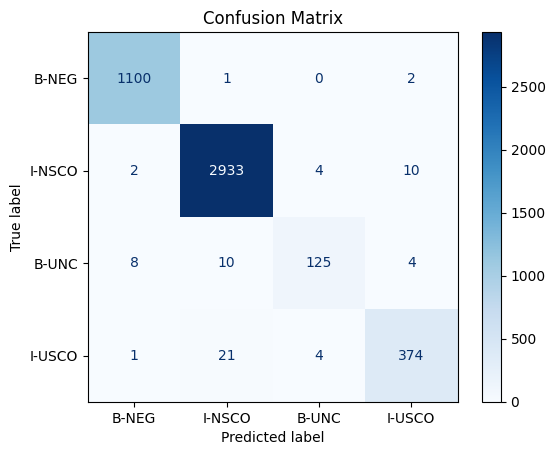

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Flatten your lists of labels if needed:
y_true_flat = [label for seq in y_test for label in seq]
y_pred_flat = [label for seq in y_pred for label in seq]

cm = confusion_matrix(y_true_flat, y_pred_flat, labels=sorted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted_labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()